In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

class HybridWindowExtractor:
    def __init__(
        self,
        hand="Right",
        window_sec=1.5,
        step_sec=0.5,
        orig_fps=30.0,
        log_transform=False
    ):
        self.hand = hand
        self.orig_fps = float(orig_fps)
        self.dt = 1.0 / self.orig_fps
        self.window_size = int(window_sec * self.orig_fps)
        self.step_size = int(step_sec * self.orig_fps)
        self.log_transform = log_transform

    def extract_features(self, df_dict):
        """
        Main pipeline: Iterates over videos -> Groups by Valid Segment -> Slides Window -> Computes Physics.
        """
        all_window_rows = []

        for video_id, df in tqdm(df_dict.items(), desc=f"Extracting {self.hand} Hybrid Features"):
            
            # 1. Filter Hand
            if 'hand_label' in df.columns:
                dfh = df[df["hand_label"] == self.hand].copy()
            else:
                dfh = df.copy()

            # 2. Iterate over CONTINUOUS segments (Implicit Validity Handling)
            # This is safer than masks because we never interpolate over huge gaps
            if 'segment_id' not in dfh.columns:
                # Fallback if segment_id missing: treat whole video as one segment (risky if gaps exist)
                dfh['segment_id'] = 0 
            
            for seg_id, df_seg in dfh.groupby('segment_id'):
                if len(df_seg) < self.window_size:
                    continue

                # 3. Pre-calculate Physical Signals for this segment
                # (Vectors, Velocities, Angles, Areas)
                signals = self._compute_segment_signals(df_seg)

                # 4. Slide Window over this segment
                T = len(signals['vx'])
                for start in range(1, T - self.window_size + 1, self.step_size):
                    end = start + self.window_size
                    
                    # Slice all signals
                    win = {k: v[start:end] for k, v in signals.items()}
                    
                    # 5. Compute Scalar Features (The "Choice" of best metrics)
                    feats = self._compute_window_metrics(win)
                    
                    # Meta-data
                    feats['video_id'] = video_id
                    feats['window_start_frame'] = df_seg.iloc[start]['frame']
                    
                    all_window_rows.append(feats)

        return pd.DataFrame(all_window_rows)

    def _compute_segment_signals(self, df_seg):
        """
        Computes the raw time-series for Translation, Rotation, and Pose.
        """
        # --- A. Extract Keypoints ---
        def get_pts(lm_prefix):
            cols = [f"{lm_prefix}_{ax}_smooth" for ax in ["x", "y"]]
            return df_seg[cols].values

        pts0 = get_pts("lm_0")   # Wrist
        pts5 = get_pts("lm_5")   # Index Base
        pts17 = get_pts("lm_17") # Pinky Base

        # --- B. Translational (Wrist) ---
        # Velocity
        v_vec = np.diff(pts0, axis=0, prepend=pts0[:1]) / self.dt
        vx, vy = v_vec[:, 0], v_vec[:, 1]
        
        # Acceleration
        a_vec = np.diff(v_vec, axis=0, prepend=v_vec[:1]) / self.dt
        ax, ay = a_vec[:, 0], a_vec[:, 1]
        
        # Displacement (Frame-to-frame distance)
        d = np.concatenate(([0], np.sqrt(np.sum(np.diff(pts0, axis=0)**2, axis=1))))

        # --- C. Rotational (Orientation) ---
        # Vector from Wrist to Index (Hand Direction)
        v_orient = pts5 - pts0
        angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
        # Unwrap to handle -pi/pi jumps smoothly
        angles_unwrapped = np.unwrap(angles)
        # Angular Velocity (rad/s)
        ang_vel = np.diff(angles_unwrapped, prepend=angles_unwrapped[0]) / self.dt

        # --- D. Pose (Palm Shape) ---
        # Triangle Area between Wrist, Index, Pinky
        v1 = pts5 - pts0
        v2 = pts17 - pts0
        # Cross product 2D for area
        palm_area = 0.5 * np.abs(v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0])

        return {
            'd': d, 'vx': vx, 'vy': vy, 'ax': ax, 'ay': ay,
            'ang_vel': ang_vel, 'palm_area': palm_area, 'pts0': pts0
        }

    def _compute_window_metrics(self, win):
        """
        Aggregates the 1.5s window into scalar features.
        """
        feats = {}
        
        # --- 0. Metadata & Idle Detection ---
        tot_path = np.sum(win['d'])
        feats['total_path'] = tot_path

        if tot_path < 20:
            d=1
        
        # We define 'idle' as moving less than 25 pixels in 1.5 seconds.
        # This feature alone is a powerful 'Economy of Motion' predictor.
        feats['is_idle'] = 1.0 if tot_path < 25 else 0.0

        # --- 1. Translational Quality ---
        
        # Path Ratio (Tortuosity)
        # Ratio of actual path length to Euclidean distance between start and end
        # Perfect straight line = 1.0. Inefficient wandering > 1.0.
        # We use win['pts0'] which should be the (N, 2) wrist coordinates
        start_pt = win['pts0'][0]
        end_pt = win['pts0'][-1]
        euclidean_dist = np.sqrt(np.sum((end_pt - start_pt)**2))
        
        # We log-transform because Path Ratio distributions are usually skewed
        path_ratio = tot_path / (euclidean_dist + 1e-6)
        feats['path_ratio'] = np.log1p(path_ratio) if self.log_transform else path_ratio

        # Curvature (Precision/Tightness of turns)
        v_mag_sq = win['vx']**2 + win['vy']**2
        cross = np.abs(win['vx'] * win['ay'] - win['vy'] * win['ax'])
        curvature = cross / (v_mag_sq**1.5 + 1e-6)
        mean_k = np.mean(curvature)
        feats['curvature'] = np.log1p(mean_k) if self.log_transform else mean_k

        # Reversals (Fluidity)
        feats['num_reversals'] = self._count_reversals(win['vx'], win['vy'])

        # --- 2. Smoothness (Jerk) ---
        # Apply the 'Idle' logic you found to stabilize the jerk formula
        jerk_x = np.diff(win['ax'], prepend=win['ax'][0]) / self.dt
        jerk_y = np.diff(win['ay'], prepend=win['ay'][0]) / self.dt
        int_sq_jerk = np.sum(jerk_x**2 + jerk_y**2) * self.dt
        duration = len(win['d']) * self.dt
        
        # If idle, we don't apply the epsilon to preserve the 'true' smoothness signal
        # or you can choose to skip jerk calculation for idle windows entirely later.
        denom_sq = (tot_path**2) if tot_path >= 0 else (tot_path + 10)**2
        dim_jerk = (duration**5 * int_sq_jerk) / (denom_sq + 1e-6)
        feats['jerk'] = np.log1p(dim_jerk) if self.log_transform else dim_jerk

        # --- 3. Rotational & Pose Dynamics ---
        feats['ang_vel_mean'] = np.mean(np.abs(win['ang_vel']))
        feats['ang_vel_std'] = np.std(win['ang_vel'])
        
        area_mean = np.mean(win['palm_area'])
        feats['palm_area_cv'] = (np.std(win['palm_area']) / area_mean) if area_mean > 1e-6 else 0.0

        # --- 4. Intensity Stats ---
        v_mag = np.sqrt(v_mag_sq)
        feats['vel_mean'] = np.mean(v_mag)
        feats['vel_p90'] = np.percentile(v_mag, 90)

        return feats

    def _count_reversals(self, vx, vy):
        """
        Vectorized Reversal Counter using Cosine Similarity windowing.
        """
        w = int(0.3 * self.orig_fps) # 300ms window for direction check
        if len(vx) <= w: return 0.0
        
        # Compare vector at T vs vector at T+w
        v_now_x, v_now_y = vx[:-w], vy[:-w]
        v_fut_x, v_fut_y = vx[w:], vy[w:]
        
        dot = v_now_x * v_fut_x + v_now_y * v_fut_y
        mag_now = np.sqrt(v_now_x**2 + v_now_y**2)
        mag_fut = np.sqrt(v_fut_x**2 + v_fut_y**2)
        
        # Filter: Must be moving to reverse (avoid noise)
        is_moving = (mag_now > 15.0) & (mag_fut > 15.0)
        
        cosine = np.ones_like(dot)
        valid = is_moving & ((mag_now * mag_fut) > 1e-6)
        cosine[valid] = dot[valid] / (mag_now[valid] * mag_fut[valid])
        
        # Threshold: < -0.7 means > 135 degree turn
        is_reversing = (cosine < -0.7).astype(int)
        
        # Count 0->1 transitions (events)
        return float(np.sum(np.diff(is_reversing, prepend=0) == 1))

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm

class HybridWindowExtractor:
    def __init__(
        self,
        hand="Right",
        window_sec=1.5,
        step_sec=0.5,
        orig_fps=30.0,
        log_transform=False,
        include_bimanual=False
    ):
        self.hand = hand
        self.other_hand = "Left" if hand == "Right" else "Right"
        self.orig_fps = float(orig_fps)
        self.dt = 1.0 / self.orig_fps
        self.window_size = int(window_sec * self.orig_fps)
        self.step_size = int(step_sec * self.orig_fps)
        self.log_transform = log_transform
        self.include_bimanual = include_bimanual

    def extract_features(self, df_dict):
        all_window_rows = []

        for video_id, df in tqdm(df_dict.items(), desc=f"Extracting {self.hand} Features"):
            # 1. Separate Hands
            # Assuming df has a 'hand_label' column. 
            if 'hand_label' in df.columns:
                df_primary = df[df["hand_label"] == self.hand].copy()
                df_other = df[df["hand_label"] == self.other_hand].copy()
            else:
                # If structure is different, assume df is already primary hand
                df_primary = df.copy()
                df_other = pd.DataFrame() # Empty

            # Ensure segmentation exists
            if 'segment_id' not in df_primary.columns:
                df_primary['segment_id'] = 0

            # 2. Iterate segments of PRIMARY hand
            for seg_id, df_seg in df_primary.groupby('segment_id'):
                if len(df_seg) < self.window_size:
                    continue

                # 3. Compute Signals (Primary)
                signals_p = self._compute_signals(df_seg)
                
                # 4. Prepare Secondary Signals (for Bimanual)
                signals_o = None
                if self.include_bimanual and not df_other.empty:
                    # Get matching frames for the other hand
                    # We merge on 'frame' to ensure strict time alignment
                    common_frames = df_seg['frame'].values
                    df_seg_other = df_other[df_other['frame'].isin(common_frames)]
                    
                    # Only calculate if we have reasonably overlapping data
                    if len(df_seg_other) > (len(df_seg) * 0.8): 
                        # Note: We need to reindex to match Primary's exact length/order for vector math
                        df_seg_other = df_seg_other.set_index('frame').reindex(common_frames).reset_index()
                        signals_o = self._compute_signals(df_seg_other)

                # 5. Slide Window
                T = len(signals_p['vx'])
                for start in range(1, T - self.window_size + 1, self.step_size):
                    end = start + self.window_size
                    
                    # Slice Primary
                    win_p = {k: v[start:end] for k, v in signals_p.items()}
                    
                    # Slice Secondary (if available)
                    win_o = None
                    if signals_o is not None:
                        # Check if secondary data is valid (not NaN from reindex)
                        # We just check a key array like 'vx'
                        if not np.isnan(signals_o['vx'][start:end]).any():
                            win_o = {k: v[start:end] for k, v in signals_o.items()}

                    # 6. Compute Features
                    feats = self._compute_all_metrics(win_p, win_o)
                    
                    feats['video_id'] = video_id
                    feats['window_start_frame'] = df_seg.iloc[start]['frame']
                    all_window_rows.append(feats)

        return pd.DataFrame(all_window_rows)

    def _compute_signals(self, df_seg):
        """ Compute raw time-series vectors from keypoints. """
        # Helper to get numpy arrays
        def get_pts(lm_prefix):
            cols = [f"{lm_prefix}_{ax}_smooth" for ax in ["x", "y"]]
            # Fill NaNs to avoid crashing, though segmenter should have handled this
            return df_seg[cols].values

        pts0 = get_pts("lm_0")   # Wrist
        pts5 = get_pts("lm_5")   # Index Base
        pts17 = get_pts("lm_17") # Pinky Base

        # Velocity & Accel
        v_vec = np.diff(pts0, axis=0, prepend=pts0[:1]) / self.dt
        a_vec = np.diff(v_vec, axis=0, prepend=v_vec[:1]) / self.dt
        
        # Speed & Path
        d = np.sqrt(np.sum(np.diff(pts0, axis=0)**2, axis=1))
        d = np.concatenate(([0], d))
        
        # Orientation (Wrist -> Index)
        v_orient = pts5 - pts0
        angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
        ang_vel = np.diff(np.unwrap(angles), prepend=angles[0]) / self.dt

        # Palm Area
        v1 = pts5 - pts0
        v2 = pts17 - pts0
        palm_area = 0.5 * np.abs(v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0])

        return {
            'pts0': pts0, 'd': d, 
            'vx': v_vec[:,0], 'vy': v_vec[:,1], 
            'ax': a_vec[:,0], 'ay': a_vec[:,1],
            'ang_vel': ang_vel, 'palm_area': palm_area
        }

    def _compute_all_metrics(self, win, win_other=None):
        """ Master feature computer that delegates to sub-methods. """
        feats = {}
        
        # Basic Metadata
        feats['total_path'] = np.sum(win['d'])
        feats['is_idle'] = 1.0 if feats['total_path'] < 25 else 0.0

        # Feature Groups
        feats.update(self._feat_translation(win))
        feats.update(self._feat_smoothness(win, feats['total_path']))
        feats.update(self._feat_rotation(win))
        feats.update(self._feat_pose(win))
        
        # Bimanual (if enabled and data exists)
        if win_other is not None:
            feats.update(self._feat_bimanual(win, win_other))
        
        return feats

    # --- Feature Modules ---

    def _feat_translation(self, win):
        f = {}
        # Path Ratio
        start_pt, end_pt = win['pts0'][0], win['pts0'][-1]
        euclidean = np.sqrt(np.sum((end_pt - start_pt)**2))
        path_ratio = np.sum(win['d']) / (euclidean + 1e-6)
        f['path_ratio'] = np.log1p(path_ratio) if self.log_transform else path_ratio

        # Curvature
        v_mag_sq = win['vx']**2 + win['vy']**2
        cross = np.abs(win['vx'] * win['ay'] - win['vy'] * win['ax'])
        k = cross / (v_mag_sq**1.5 + 0.5)
        f['curvature'] = np.log1p(np.mean(k)) if self.log_transform else np.mean(k)

        # Reversals
        f['num_reversals'] = self._count_reversals(win['vx'], win['vy'])
        
        # Velocity Stats
        v_mag = np.sqrt(v_mag_sq)
        f['vel_mean'] = np.mean(v_mag)
        f['vel_p90'] = np.percentile(v_mag, 90)

        # Calculate the spatial dispersion (Work Envelope)
        # High value = Wandering/Drifting; Low value = Focused/Steady
        pts = win['pts0'] # (N, 2) array of wrist coordinates
        spatial_std = np.sqrt(np.std(pts[:, 0])**2 + np.std(pts[:, 1])**2)
        f['spatial_spread'] = np.log1p(spatial_std) if self.log_transform else spatial_std
        
        return f

    def _feat_smoothness(self, win, total_path):
        f = {}
        # Jerk Calculation
        jerk_x = np.diff(win['ax'], prepend=win['ax'][0]) / self.dt
        jerk_y = np.diff(win['ay'], prepend=win['ay'][0]) / self.dt
        int_sq_jerk = np.sum(jerk_x**2 + jerk_y**2) * self.dt
        duration = len(win['d']) * self.dt

        # Logic Fix: Only use the raw path if it is substantial (>15px)
        # Otherwise, add epsilon to prevent explosion
        denom = (total_path) if total_path > 0 else (total_path + 10)
        dim_jerk = (duration**5 * int_sq_jerk) / (denom**2 + 1e-6)
        
        f['jerk'] = np.log1p(dim_jerk) if self.log_transform else dim_jerk
        return f

    def _feat_rotation(self, win):
        return {
            'ang_vel_mean': np.mean(np.abs(win['ang_vel'])),
            'ang_vel_std': np.std(win['ang_vel'])
        }

    def _feat_pose(self, win):
        area_mean = np.mean(win['palm_area'])
        cv = (np.std(win['palm_area']) / area_mean) if area_mean > 1e-6 else 0.0
        return {'palm_area_cv': cv}

    def _feat_bimanual(self, win_p, win_o):
        """ 
        Calculates coordination between Primary (p) and Other (o) hand.
        """
        f = {}
        
        # 1. Inter-hand Distance (Proximity)
        # Are they working close together (Expert) or scared of collision (Novice)?
        dist_vec = win_p['pts0'] - win_o['pts0']
        dist = np.sqrt(np.sum(dist_vec**2, axis=1))
        f['bimanual_dist_mean'] = np.mean(dist)
        f['bimanual_dist_std'] = np.std(dist) # Fixed distance = good holding

        # 2. Velocity Correlation (Synchrony)
        # Do they start/stop together?
        vp_mag = np.sqrt(win_p['vx']**2 + win_p['vy']**2)
        vo_mag = np.sqrt(win_o['vx']**2 + win_o['vy']**2)
        
        # Pearson correlation of speed profiles
        if np.std(vp_mag) > 1e-6 and np.std(vo_mag) > 1e-6:
            f['bimanual_sync'] = np.corrcoef(vp_mag, vo_mag)[0,1]
        else:
            f['bimanual_sync'] = 0.0

        # 3. Dominance Ratio (Activity Balance)
        # 0.5 = Equal usage, 1.0 = Primary only, 0.0 = Other only
        sum_vp = np.sum(vp_mag)
        sum_vo = np.sum(vo_mag)
        f['bimanual_ratio'] = sum_vp / (sum_vp + sum_vo + 1e-6)

        return f

    def _count_reversals(self, vx, vy):
        # (Same robust implementation as before)
        w = int(0.3 * self.orig_fps)
        if len(vx) <= w: return 0.0
        
        v_now_x, v_now_y = vx[:-w], vy[:-w]
        v_fut_x, v_fut_y = vx[w:], vy[w:]
        
        dot = v_now_x * v_fut_x + v_now_y * v_fut_y
        mag_now = np.sqrt(v_now_x**2 + v_now_y**2)
        mag_fut = np.sqrt(v_fut_x**2 + v_fut_y**2)
        
        is_moving = (mag_now > 15.0) & (mag_fut > 15.0)
        
        cosine = np.ones_like(dot)
        valid = is_moving & ((mag_now * mag_fut) > 1e-6)
        cosine[valid] = dot[valid] / (mag_now[valid] * mag_fut[valid])
        
        return float(np.sum(np.diff((cosine < -0.7).astype(int), prepend=0) == 1))

In [3]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

In [4]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:02<00:00, 28.85it/s]


In [5]:
# 1. Initialize and Prepare Data
extractor = HybridWindowExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=True)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [00:46<00:00,  1.78it/s]


In [6]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

# !!!might want to apply a log transform prior to video level aggregation to some more features!!!
df_window_features[feature_cols].describe()

,total_path,is_idle,path_ratio,curvature,num_reversals,vel_mean,vel_p90,spatial_spread,jerk,ang_vel_mean,ang_vel_std,palm_area_cv,bimanual_dist_mean,bimanual_dist_std,bimanual_sync,bimanual_ratio
count,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,6.680500e+04,66805.000000,66805.000000,66805.000000,49397.000000,49397.000000,49397.000000,49397.000000
mean,158.748090,0.095996,5.593937,1.240816,2.345199,105.832060,211.767129,26.701205,1.038975e+06,0.666374,0.936019,0.264347,463.776654,18.335328,0.136200,0.625373
std,146.390429,0.294588,11.842887,1.918901,1.831621,97.593619,215.903027,33.447463,1.780863e+06,0.848246,1.488702,0.248197,102.502598,22.112861,0.350688,0.218447
min,3.876668,0.000000,1.009416,0.001791,0.000000,2.584445,4.165599,0.279839,7.347033e+03,0.012433,0.015308,0.002284,96.097205,0.306240,-0.828705,0.017242
25%,51.629718,0.000000,1.657437,0.212678,1.000000,34.419812,65.360279,7.666133,3.796996e+05,0.141644,0.168370,0.052784,395.228938,5.690995,-0.125747,0.468773
50%,113.647418,0.000000,2.690903,0.535194,2.000000,75.764945,146.381519,16.005497,6.413851e+05,0.365893,0.448227,0.173780,464.745646,10.839420,0.102558,0.635996
75%,220.021096,0.000000,5.537311,1.479477,4.000000,146.680731,278.989377,29.556090,1.110723e+06,0.837948,1.047698,0.444270,527.412461,21.298246,0.377415,0.810858
max,1311.611813,1.000000,683.892277,54.605934,10.000000,874.407875,2293.410623,374.758455,6.656510e+07,12.414626,18.612265,1.751071,1559.975878,370.469011,0.994122,0.989285


In [7]:
import numpy as np
import pandas as pd
from scipy.stats import iqr

def calculate_window_distributions(df_windows, feature_cols, group_col='video_id'):
    """
    Aggregates window-level local features into video-level distribution features.
    
    Args:
        df_windows (pd.DataFrame): DataFrame containing 1.5s window features.
        feature_cols (list): List of columns to aggregate (v, a, curvature, etc.).
        window_id_col (str): Column identifying the video/surgeon.
        
    Returns:
        pd.DataFrame: One row per video with aggregated distribution features.
    """
    
    # Define the aggregations we want
    # We use a dictionary to rename them nicely later
    aggs = {}
    for col in feature_cols:
        aggs[col] = [
            'median',
            'mean', 
            'std', 
            lambda x: np.percentile(x, 10), 
            lambda x: np.percentile(x, 90)
        ]

    # Perform the GroupBy Aggregation
    print(f"Aggregating {len(feature_cols)} features across {df_windows[group_col].nunique()} videos...")
    df_agg = df_windows.groupby(group_col)[feature_cols].agg(aggs)
    
    # Flatten the MultiIndex columns (e.g., ('velocity', 'mean') -> 'velocity_mean')
    new_cols = []
    for col_name, stat_name in df_agg.columns:
        if '<lambda_0>' in str(stat_name):
            stat_label = 'p10'
        elif '<lambda_1>' in str(stat_name):
            stat_label = 'p90'
        else:
            stat_label = stat_name
            
        new_cols.append(f"{col_name}_{stat_label}")
    
    df_agg.columns = new_cols
    df_agg.reset_index(inplace=True)
    
    return df_agg

# Example Usage Hypothesis Check:
# 1. Run this function on your 3s window dataframe.
# 2. Merge the result with your target scores (QRS).
# 3. Run your 'leakage_free_residual_analysis' on these new columns (e.g., 'curvature_p90').

df_agg = calculate_window_distributions(df_window_features, feature_cols, group_col='video_id')

Aggregating 16 features across 83 videos...


In [8]:
df_window_features.columns

Index(['total_path', 'is_idle', 'path_ratio', 'curvature', 'num_reversals',
       'vel_mean', 'vel_p90', 'spatial_spread', 'jerk', 'ang_vel_mean',
       'ang_vel_std', 'palm_area_cv', 'bimanual_dist_mean',
       'bimanual_dist_std', 'bimanual_sync', 'bimanual_ratio', 'video_id',
       'window_start_frame'],
      dtype='object')

In [9]:
def aggregate_hybrid_features(df_windows):
    """
    Performs conditional aggregation:
    1. Overall Economy (Idle vs Active)
    2. Kinematic Quality (Only during active movement)
    """
    
    # --- 1. Global Economy of Motion (Dwell Time) ---
    # This captures the 'Indecision' signal you found
    df_economy = df_windows.groupby('video_id')['is_idle'].agg(['mean']).rename(columns={'mean': 'idle_proportion'})

    # --- 2. Active Kinematics (The 'Pure' Signal) ---
    # We filter out idle windows to ensure Jerk/Curvature measure REAL movement
    df_active = df_windows[df_windows['is_idle'] == 0].copy()
    
    # Choose features that describe 'Execution Quality'
    kinematic_cols = [
        'jerk', 'curvature', 'path_ratio', 'num_reversals', 
        'ang_vel_std', 'ang_vel_mean', 'palm_area_cv', 'vel_mean', 'vel_p90',
        'spatial_spread', 'bimanual_dist_mean', 'bimanual_dist_std', 'bimanual_sync', 'bimanual_ratio'
    ]
    #    'bimanual_dist_mean', 'bimanual_dist_std', 'bimanual_sync', 'bimanual_ratio'

    
    
    # We use Median for typical behavior and P90/Std for inconsistency/extremes
    kinematic_aggs = {}
    for col in kinematic_cols:
        kinematic_aggs[col] = ['median', 'std', lambda x: np.percentile(x, 90), lambda x: np.percentile(x, 10)]

    df_kinematics = df_active.groupby('video_id')[kinematic_cols].agg(kinematic_aggs)
    
    # Flatten MultiIndex columns
    new_cols = []
    for col, stat in df_kinematics.columns:
        stat_label = 'p90' if 'lambda_0' in str(stat) else ('p10' if 'lambda_1' in str(stat) else stat)
        new_cols.append(f"{col}_{stat_label}")
    df_kinematics.columns = new_cols

    # --- 3. Merge and Return ---
    df_final = df_economy.join(df_kinematics, how='left').fillna(0)
    
    # Important: Some very fast surgeons might have 0 idle windows, 
    # and some very slow ones might have 0 active windows (rare).
    # Fillna(0) ensures the matrix remains complete for Ridge Regression.
    
    return df_final.reset_index()

# Usage
df_window_features['is_idle'] = (df_window_features['total_path'] < 15).astype(int)
df_agg = aggregate_hybrid_features(df_window_features)

In [10]:
df_agg[[col for col in df_agg.columns if 'video_id' not in col]].describe()

,idle_proportion,jerk_median,jerk_std,jerk_p90,jerk_p10,curvature_median,curvature_std,curvature_p90,curvature_p10,path_ratio_median,...,bimanual_dist_std_p90,bimanual_dist_std_p10,bimanual_sync_median,bimanual_sync_std,bimanual_sync_p90,bimanual_sync_p10,bimanual_ratio_median,bimanual_ratio_std,bimanual_ratio_p90,bimanual_ratio_p10
count,83.000000,83.000000,8.300000e+01,8.300000e+01,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,...,83.0,83.0,83.000000,83.000000,83.0,83.0,83.000000,83.000000,83.0,83.0
mean,0.032957,649925.452282,1.399119e+06,1.861513e+06,228477.000528,0.512419,1.698059,2.799849,0.107396,2.873088,...,0.0,0.0,0.109095,0.350298,0.0,0.0,0.644812,0.208624,0.0,0.0
std,0.025922,110133.703139,7.869544e+05,4.725806e+05,41212.260292,0.141895,0.447817,0.477621,0.022106,0.597639,...,0.0,0.0,0.049758,0.016387,0.0,0.0,0.078558,0.024093,0.0,0.0
min,0.000000,422506.638882,5.224032e+05,1.072508e+06,128076.402348,0.212990,1.062903,1.789936,0.060544,2.184782,...,0.0,0.0,-0.005708,0.307869,0.0,0.0,0.498327,0.147968,0.0,0.0
25%,0.012917,582320.662060,8.761283e+05,1.588484e+06,194980.219281,0.406784,1.406977,2.409841,0.090680,2.469525,...,0.0,0.0,0.075231,0.338190,0.0,0.0,0.581429,0.193700,0.0,0.0
50%,0.026764,644688.561129,1.133269e+06,1.772974e+06,229456.097464,0.478212,1.609338,2.791749,0.107403,2.694778,...,0.0,0.0,0.102240,0.350964,0.0,0.0,0.653300,0.211969,0.0,0.0
75%,0.044272,711737.800970,1.673831e+06,2.088216e+06,256564.535028,0.610327,1.845685,3.193067,0.119277,3.174184,...,0.0,0.0,0.139214,0.363565,0.0,0.0,0.693210,0.223961,0.0,0.0
max,0.126354,927405.682184,5.746716e+06,3.588767e+06,319101.450528,0.882514,3.233961,3.794927,0.173204,4.704329,...,0.0,0.0,0.245799,0.380252,0.0,0.0,0.866681,0.285517,0.0,0.0


# Compute correlations between features and scores

In [11]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in df_agg.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_agg[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
bimanual_ratio_p10:        Pearson r = nan, Spearman rho = nan
bimanual_ratio_p90:        Pearson r = nan, Spearman rho = nan
bimanual_sync_p10:        Pearson r = nan, Spearman rho = nan
bimanual_sync_p90:        Pearson r = nan, Spearman rho = nan
bimanual_dist_mean_p90:        Pearson r = nan, Spearman rho = nan
bimanual_dist_std_p10:        Pearson r = nan, Spearman rho = nan
bimanual_dist_std_p90:        Pearson r = nan, Spearman rho = nan
bimanual_dist_mean_p10:        Pearson r = nan, Spearman rho = nan
num_reversals_std:        Pearson r = 0.3982, Spearman rho = 0.4102
path_ratio_p90:        Pearson r = 0.3922, Spearman rho = 0.4526
palm_area_cv_median:        Pearson r = 0.3713, Spearman rho = 0.3664
idle_proportion:        Pearson r = 0.3650, Spearman rho = 0.3161


/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_53470/1688577433.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_53470/1688577433.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)


# Compute correlations with residuals

In [12]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
combined_df = pd.merge(df_top_features, df_agg, left_index=True, right_index=True)

In [13]:
df_top_features.columns

Index(['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal',
       'velocity_corr', 'num_reversals_Right', 'total_duration_Left',
       'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left',
       'total_angular_path_Right'],
      dtype='object')

In [14]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0],
    pca_features=['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right'],
    n_top_features=5
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = Ridge(alpha=0.5)
        pc_model.fit(df_train[used_pc_cols+['velocity_corr']], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols+['velocity_corr']])
        #random.shuffle(train_residuals)
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols+['velocity_corr']+[feat]]
            scaler_full = StandardScaler()
            X_full = scaler_full.fit_transform(X_full)
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']

    results_df['Resid_Corr'] = results_df['Resid_Corr'].abs()

    min_res_corr = results_df['Resid_Corr'].min()
    max_res_corr = results_df['Resid_Corr'].max()
    min_partial_r2 = results_df['Partial_R2'].min()
    max_partial_r2 = results_df['Partial_R2'].max()

    results_df['rank_score'] = ((results_df['Resid_Corr'].abs() - min_res_corr) / (max_res_corr - min_res_corr)) * ((results_df['Partial_R2'].abs() - min_partial_r2) / (max_partial_r2 - min_partial_r2))
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['rank_score'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= n_top_features]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    rank_score = results_df.groupby('Feature')['rank_score'].mean().reset_index().rename(columns={0: 'Mean_Rank_Score', 'index': 'Feature'})
    final_summary = summary.merge(rank_score, on='Feature', how='left').fillna(0)
    final_summary = final_summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('rank_score', ascending=False)    

# Usage:
#exploratory_cols.remove('velocity_corr_moving')
candidate_features = [col for col in combined_df.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr', 'total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right', 'video_id']]

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(combined_df, candidate_features, n_top_features=5, pca_features=['num_reversals_Right', 'total_duration_Left', 'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left', 'total_angular_path_Right'])
df_res_leakage_free

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_53470/2423670521.py:65: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(df_train[feat], train_residuals)
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_53470/2423670521.py:65: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(df_train[feat], train_residuals)
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_53470/2423670521.py:65: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(df_train[feat], train_residuals)
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_53470/2423670521.py:65: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(df_train[feat], train_residuals)
/var/folders/sj/219f9qbn3y15yynsh

,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,rank_score,Selection_Stability
38,palm_area_cv_median,0.096389,0.009756,0.292105,0.016861,0.632790,1.000000
28,idle_proportion,0.093149,0.011144,0.267528,0.018400,0.558481,0.964286
32,jerk_std,0.099136,0.011404,0.248623,0.019050,0.557939,0.964286
48,spatial_spread_p90,0.097469,0.011750,-0.217795,0.022737,0.481049,0.928571
45,path_ratio_std,0.074178,0.008435,0.229747,0.017992,0.366778,0.607143
40,palm_area_cv_p90,0.067217,0.009361,0.226190,0.017761,0.321049,0.178571
25,curvature_p10,0.076802,0.009941,0.183572,0.019324,0.306925,0.142857
42,path_ratio_median,0.063321,0.007543,0.220985,0.017844,0.290878,0.035714
30,jerk_p10,0.063429,0.012560,0.200973,0.029552,0.271006,0.035714
58,vel_p90_p90,0.080640,0.010489,-0.145656,0.021675,0.259443,0.035714


# Try different forms of feature selection

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

def nested_loso_feature_selection(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0],
    pca_features=['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right'],
    k_best_features=3  # How many local features to auto-select per fold
):
    unique_surgeons = df[surgeon_col].unique()
    
    predictions = []
    actuals = []
    selection_history = []
    
    # We will track which features were selected in each fold
    feature_counts = {f: 0 for f in candidate_features}

    for surgeon_out in tqdm(unique_surgeons, desc="Running Nested LOSO"):
        # --- 1. Split Data ---
        train_mask = df[surgeon_col] != surgeon_out
        test_mask = df[surgeon_col] == surgeon_out
        
        df_train = df[train_mask].dropna(subset=[target] + candidate_features + pca_features).copy()
        df_test = df[test_mask].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        if len(df_test) == 0: continue

        y_train = df_train[target].values
        y_test = df_test[target].values

        # --- 2. Global Features (PCA) ---
        # Fit scaler and PCA on TRAIN only
        scaler_pca = StandardScaler()
        X_train_pca_raw = scaler_pca.fit_transform(df_train[pca_features])
        X_test_pca_raw = scaler_pca.transform(df_test[pca_features]) # Apply to test
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        test_pcs = pca.transform(X_test_pca_raw)
        
        # Prepare Global Feature Matrix
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        X_train_global = pd.DataFrame(train_pcs, columns=pc_cols, index=df_train.index)
        X_test_global = pd.DataFrame(test_pcs, columns=pc_cols, index=df_test.index)
        
        # Add Velocity Correlation (Hybrid feature)
        X_train_global['velocity_corr'] = df_train['velocity_corr']
        X_test_global['velocity_corr'] = df_test['velocity_corr']
        
        base_features = [pc_cols[i] for i in pcs_to_use] + ['velocity_corr']

        # --- 3. Residual Analysis (ON TRAIN DATA ONLY) ---
        # We need to find which features explain the residuals of the N-1 surgeons
        
        # Baseline Model
        base_model = Ridge(alpha=0.5)
        base_model.fit(X_train_global[base_features], y_train)
        train_residuals = y_train - base_model.predict(X_train_global[base_features])
        base_resid_var = np.var(train_residuals)

        # Rank Candidates
        feature_scores = []
        
        # Pre-calculate Scalers for candidates to speed up loop
        # (Strictly we should fit scaler inside loop, but fit/transform separation is enough here)
        scaler_cand = StandardScaler()
        X_train_cand_all = scaler_cand.fit_transform(df_train[candidate_features])
        
        for idx, feat in enumerate(candidate_features):
            # Get feature column
            x_feat = X_train_cand_all[:, idx].reshape(-1, 1)
            
            # Partial R2 Check
            # Combine Base + New Feature
            X_combined = np.hstack([X_train_global[base_features].values, x_feat])
            
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_combined, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_combined))
            partial_r2 = 1 - (full_resid_var / base_resid_var)
            
            # Correlation Check
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            feature_scores.append({
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': abs(r)
            })
            
        # --- 4. Select Top K Features ---
        scores_df = pd.DataFrame(feature_scores)
        
        # Your Ranking Logic (Normalized)
        min_r2, max_r2 = scores_df['Partial_R2'].min(), scores_df['Partial_R2'].max()
        min_corr, max_corr = scores_df['Resid_Corr'].min(), scores_df['Resid_Corr'].max()
        
        # Avoid division by zero if all scores are identical
        denom_r2 = (max_r2 - min_r2) if (max_r2 - min_r2) > 1e-9 else 1.0
        denom_corr = (max_corr - min_corr) if (max_corr - min_corr) > 1e-9 else 1.0
        
        scores_df['rank_score'] = (
            ((scores_df['Partial_R2'] - min_r2) / denom_r2) * ((scores_df['Resid_Corr'] - min_corr) / denom_corr)
        )
        
        top_k_features = scores_df.sort_values('rank_score', ascending=False).head(k_best_features)['Feature'].tolist()
        
        # Log selection
        for f in top_k_features:
            feature_counts[f] += 1
        selection_history.append(top_k_features)

        # --- 5. Train Final Model & Predict Test ---
        # We now train a model on Global + Top K Local Features
        final_features = base_features + top_k_features
        
        # Prepare Final Matrices
        X_train_final = X_train_global[base_features].copy()
        X_test_final = X_test_global[base_features].copy()
        
        # Add the selected local features (Scaled!)
        # Important: Must re-scale based on training stats of THIS fold
        scaler_final_local = StandardScaler()
        X_train_local = scaler_final_local.fit_transform(df_train[top_k_features])
        X_test_local = scaler_final_local.transform(df_test[top_k_features])
        
        X_train_final = np.hstack([X_train_final.values, X_train_local])
        X_test_final = np.hstack([X_test_final.values, X_test_local])
        
        # Fit & Predict
        final_model = Ridge(alpha=0.5)
        final_model.fit(X_train_final, y_train)
        y_pred = final_model.predict(X_test_final)
        
        predictions.extend(y_pred)
        actuals.extend(y_test)

    # --- 6. Final Evaluation ---
    r2_overall = r2_score(actuals, predictions)
    mae_overall = mean_absolute_error(actuals, predictions)
    std_overall = np.std(np.abs(np.array(actuals) - np.array(predictions)))
    corr_overall, _ = spearmanr(actuals, predictions)
    
    # selection stability
    stability_df = pd.DataFrame(list(feature_counts.items()), columns=['Feature', 'Count'])
    stability_df['Frequency'] = stability_df['Count'] / len(unique_surgeons)
    stability_df = stability_df.sort_values('Count', ascending=False)
    
    print(f"=== Nested LOSO Results (k={k_best_features}) ===")
    print(f"Correlation: {corr_overall:.4f}")
    print(f"R2 Score:    {r2_overall:.4f}")
    print(f"MAE:         {mae_overall:.4f}")
    print(f"Std Dev Err: {std_overall:.4f}")
    
    return stability_df, pd.DataFrame({'Actual': actuals, 'Predicted': predictions})

# RUN IT
# Only feed in your "Physically Grounded" list + Idle features
candidate_features = [col for col in combined_df.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr', 'total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right', 'video_id']]

stability, preds = nested_loso_feature_selection(combined_df, candidate_features, k_best_features=6)
display(stability.head(10))

Running Nested LOSO:   0%|          | 0/28 [00:00<?, ?it/s]


KeyError: ['total_duration_Right']

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr
from tqdm import tqdm

def nested_loso_sfs(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0],
    pca_features=['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right'],
    k_features_to_select=3
):
    unique_surgeons = df[surgeon_col].unique()
    
    predictions = []
    actuals = []
    # We will track the sets of features selected in each fold
    selection_history = [] 

    for surgeon_out in tqdm(unique_surgeons, desc="Running Nested SFS"):
        # --- 1. Split Data ---
        train_mask = df[surgeon_col] != surgeon_out
        test_mask = df[surgeon_col] == surgeon_out
        
        df_train = df[train_mask].dropna(subset=[target] + candidate_features + pca_features).copy()
        df_test = df[test_mask].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        if len(df_test) == 0: continue

        y_train = df_train[target].values
        
        # --- 2. Global Features (Base Model) ---
        scaler_pca = StandardScaler()
        X_train_pca_raw = scaler_pca.fit_transform(df_train[pca_features])
        X_test_pca_raw = scaler_pca.transform(df_test[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        test_pcs = pca.transform(X_test_pca_raw)
        
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        X_train_global = pd.DataFrame(train_pcs, columns=pc_cols, index=df_train.index)
        X_test_global = pd.DataFrame(test_pcs, columns=pc_cols, index=df_test.index)
        
        X_train_global['velocity_corr'] = df_train['velocity_corr']
        X_test_global['velocity_corr'] = df_test['velocity_corr']
        
        base_features = [pc_cols[i] for i in pcs_to_use] + ['velocity_corr']
        
        # --- 3. Sequential Forward Selection (The Smart Loop) ---
        # We start with the base features and iteratively add the best local feature
        current_features = base_features.copy()
        candidates_pool = candidate_features.copy()
        
        # Prepare Candidate Matrix (Scaled once to save time)
        scaler_cand = StandardScaler()
        X_train_cand_all = pd.DataFrame(
            scaler_cand.fit_transform(df_train[candidate_features]), 
            columns=candidate_features, 
            index=df_train.index
        )
        # We need the global features in the same DF for easy concatenation
        X_train_current = X_train_global[base_features].copy()
        
        selected_local_features = []

        for _ in range(k_features_to_select):
            best_candidate = None
            best_score = -np.inf # We want to maximize Partial R2
            
            # Train current model to get residuals
            model_curr = Ridge(alpha=0.5)
            model_curr.fit(X_train_current, y_train)
            curr_residuals = y_train - model_curr.predict(X_train_current)
            curr_resid_var = np.var(curr_residuals)
            
            # Test every remaining candidate against the CURRENT residuals
            for cand in candidates_pool:
                # Form temporary X with new candidate
                X_temp = np.hstack([X_train_current.values, X_train_cand_all[[cand]].values])
                
                # Fit temp model
                model_temp = Ridge(alpha=0.5)
                model_temp.fit(X_temp, y_train)
                
                # Check improvement
                new_resid_var = np.var(y_train - model_temp.predict(X_temp))
                partial_r2 = 1 - (new_resid_var / curr_resid_var)
                
                # Simple Score: Just use Partial R2 (Correlation is implicit in R2)
                if partial_r2 > best_score:
                    best_score = partial_r2
                    best_candidate = cand
            
            # Add the winner to the current set
            if best_candidate is not None:
                selected_local_features.append(best_candidate)
                current_features.append(best_candidate)
                candidates_pool.remove(best_candidate)
                
                # Update X_train_current for next iteration
                X_train_current = pd.concat([X_train_current, X_train_cand_all[[best_candidate]]], axis=1)
            else:
                break # No improvement found (rare)

        selection_history.append(selected_local_features)

        # --- 4. Final Prediction on Test Surgeon ---
        # Re-construct the Final Feature set for Train and Test
        # (We need to scale the selected local features on Test data properly)
        
        # Base
        X_test_final = X_test_global[base_features].copy()
        
        # Local (Scale based on Train parameters!)
        if selected_local_features:
            scaler_final_local = StandardScaler()
            X_train_local_sel = scaler_final_local.fit_transform(df_train[selected_local_features])
            X_test_local_sel = scaler_final_local.transform(df_test[selected_local_features])
            
            # Stack
            X_train_final_np = np.hstack([X_train_global[base_features].values, X_train_local_sel])
            X_test_final_np = np.hstack([X_test_final.values, X_test_local_sel])
        else:
            X_train_final_np = X_train_global[base_features].values
            X_test_final_np = X_test_final.values

        # Final Fit & Predict
        final_model = Ridge(alpha=0.5)
        final_model.fit(X_train_final_np, y_train)
        predictions.extend(final_model.predict(X_test_final_np))
        actuals.extend(df_test[target].values)

    # --- 5. Summary ---
    r2_overall = r2_score(actuals, predictions)
    mae_overall = mean_absolute_error(actuals, predictions)
    corr_overall, _ = spearmanr(actuals, predictions)
    std_overall = np.std(np.abs(np.array(actuals) - np.array(predictions))) 
    
    # Selection Frequency Analysis
    all_selected = [item for sublist in selection_history for item in sublist]
    stability_df = pd.Series(all_selected).value_counts().reset_index()
    stability_df.columns = ['Feature', 'Count']
    stability_df['Frequency'] = stability_df['Count'] / len(unique_surgeons)
    
    print(f"=== Nested SFS Results (k={k_features_to_select}) ===")
    print(f"Correlation: {corr_overall:.4f}")
    print(f"R2 Score:    {r2_overall:.4f}")
    print(f"MAE:         {mae_overall:.4f}")
    print(f"Std Dev Err: {std_overall:.4f}")
    
    return stability_df, pd.DataFrame({'Actual': actuals, 'Predicted': predictions})

# Usage
# grounded_candidates = ['idle_proportion', 'jerk_std', 'path_ratio_std', 'palm_area_cv_median', ...]
stability, preds = nested_loso_sfs(combined_df, candidate_features, k_features_to_select=2)
display(stability.head(10))

Running Nested SFS: 100%|██████████| 28/28 [00:04<00:00,  5.71it/s]

=== Nested SFS Results (k=2) ===
Correlation: 0.7331
R2 Score:    0.4964
MAE:         5.3372
Std Dev Err: 3.8918


,Feature,Count,Frequency
0,palm_area_cv_median,27,0.964286
1,spatial_spread_median,16,0.571429
2,idle_proportion,8,0.285714
3,vel_mean_p90,3,0.107143
4,ang_vel_std_median,1,0.035714
5,path_ratio_std,1,0.035714


# BoW Approach

**Need to scale features before k-means clustering**

- First do it with a little data leakage
- But for the final results need to do this within each fold!

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import MiniBatchKMeans

In [ ]:
# 1. Initialize and Prepare Data
extractor = HybridWindowExtractor(hand="Right", window_sec=2.0, step_sec=0.7, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [00:32<00:00,  2.57it/s]


In [ ]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]
df_window_features['is_idle'] = (df_window_features['total_path'] < 20).astype(int)
# !!!might want to apply a log transform prior to video level aggregation to some more features!!!
df_window_features[feature_cols].describe()

# good comb is window=2.0, step=0.5, < 30px idle, 20 clusters
# window=2.0, step=0.7, < 20px idle, 20 clusters, top 5 features

,total_path,is_idle,path_ratio,curvature,num_reversals,vel_mean,vel_p90,spatial_spread,jerk,ang_vel_mean,ang_vel_std,palm_area_cv
count,46350.000000,46350.000000,46350.000000,46350.000000,46350.000000,46350.000000,46350.000000,46350.000000,4.635000e+04,46350.000000,46350.000000,46350.000000
mean,208.001178,0.026516,6.803844,1.251692,3.281575,104.000589,215.021346,30.970895,3.229976e+06,0.649929,0.954974,0.283398
std,178.423336,0.160665,19.802666,1.732004,2.381998,89.211668,208.007733,37.001071,5.122495e+06,0.786329,1.433155,0.249326
min,5.782151,0.000000,1.010117,0.004953,0.000000,2.891076,4.789352,0.369453,2.960474e+04,0.016659,0.019565,0.002598
25%,71.828812,0.000000,1.846407,0.244152,1.000000,35.914406,70.354915,9.509592,1.249576e+06,0.147171,0.183451,0.065433
50%,155.103666,0.000000,3.104543,0.594389,3.000000,77.551833,153.156070,18.624614,2.062613e+06,0.374639,0.482411,0.207553
75%,292.670901,0.000000,6.627486,1.567342,5.000000,146.335451,286.426075,34.884419,3.484312e+06,0.838682,1.094906,0.470228
max,1667.382609,1.000000,2628.967897,40.987143,13.000000,833.691305,2061.284416,348.994543,1.975468e+08,11.567464,17.810987,1.803582


In [ ]:
df = df_window_features[df_window_features['is_idle'] == 0].copy()

In [ ]:
clip = 10.0

def prepare_clustering_data(df_windows, feature_cols):
    X = df_windows[feature_cols].copy()
    
    # 1. Log Transform sensitive kinematic features
    log_targets = [c for c in feature_cols if any(x in c for x in ['jerk', 'curvature', 'path_ratio', 'spatial_spread'])]
    for col in log_targets:
        X[col] = np.log1p(X[col])
        
    # 2. Robust Scaling (Handles outliers better than StandardScaler)
    # This uses the interquartile range (IQR)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Clip to 3 standard deviations (Manual "Extreme" handling)
    X_scaled = np.clip(X_scaled, -clip, clip)
    
    return X_scaled, scaler

# Workflow
clustering_features = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame', 'is_idle', 'num_reversals', 'vel_p90']]
X_for_km, scaler = prepare_clustering_data(df, clustering_features)
pd.DataFrame(X_for_km, columns=clustering_features).describe()

,total_path,path_ratio,curvature,vel_mean,spatial_spread,jerk,ang_vel_mean,ang_vel_std,palm_area_cv
count,45121.000000,45121.000000,45121.000000,45121.000000,45121.000000,45121.000000,45121.000000,45121.000000,45121.000000
mean,0.238676,0.220401,0.239969,0.238676,0.032091,0.005029,0.393903,0.506273,0.176180
std,0.809613,0.764939,0.743271,0.809613,0.779347,0.853533,1.122594,1.489303,0.614566
min,-0.640384,-0.711830,-0.654337,-0.640384,-1.934559,-4.261096,-0.533660,-0.525524,-0.535194
25%,-0.377790,-0.368589,-0.345621,-0.377790,-0.494939,-0.498961,-0.329559,-0.328118,-0.363074
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.622210,0.631411,0.654379,0.622210,0.505061,0.501039,0.670441,0.671882,0.636926
max,6.854273,6.471860,4.860946,6.854273,2.401726,4.630755,10.000000,10.000000,3.914531


In [ ]:
N_CLUSTERS = 30
RANDOM_STATE = 42
N_INIT = 5

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
kmeans.fit(X_for_km)

bow_features = []

for vid, group in df.groupby('video_id'):
    # 1. Log Transform sensitive kinematic features
    log_targets = [c for c in feature_cols if any(x in c for x in ['jerk', 'curvature', 'path_ratio', 'spatial_spread'])]
    X = group[clustering_features].copy()
    for col in log_targets:
        X[col] = np.log1p(X[col])
    X_vid =  scaler.transform(X)
    X_vid = np.clip(X_vid, -clip, clip)
    cluster_labels = kmeans.predict(X_vid)
    
    # Build histogram
    hist, _ = np.histogram(cluster_labels, bins=np.arange(N_CLUSTERS + 1))
    hist = hist / np.sum(hist)  # Normalize to get proportions
    
    bow_features.append((vid, hist))

col_names = [f'BoW_{i}' for i in range(N_CLUSTERS)]
bow_df = pd.DataFrame([x[1] for x in bow_features], columns=col_names)  
bow_df['video_id'] = [x[0] for x in bow_features]   

bow_df[[col for col in bow_df.columns if col != 'video_id']].describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,...,BoW_20,BoW_21,BoW_22,BoW_23,BoW_24,BoW_25,BoW_26,BoW_27,BoW_28,BoW_29
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.023628,0.045841,0.077944,0.008951,0.035122,0.017916,0.035649,0.029978,0.009925,0.063244,...,0.010413,0.051666,0.045240,0.009306,0.032422,0.021942,0.025700,0.009871,0.016892,0.033824
std,0.010600,0.018851,0.029418,0.012515,0.051715,0.011946,0.022954,0.016185,0.006480,0.046068,...,0.007063,0.030535,0.015226,0.008139,0.027428,0.016923,0.016435,0.012666,0.008058,0.014046
min,0.002959,0.018462,0.018750,0.000000,0.000000,0.002320,0.000000,0.006061,0.000000,0.002841,...,0.000000,0.000000,0.010989,0.000000,0.000000,0.000000,0.002320,0.000000,0.002083,0.007958
25%,0.017809,0.029919,0.052582,0.002003,0.002497,0.009817,0.019981,0.018923,0.005400,0.034349,...,0.005392,0.029757,0.036167,0.003454,0.013597,0.009050,0.013632,0.002152,0.011375,0.023578
50%,0.023064,0.041186,0.077083,0.006723,0.015737,0.015126,0.030952,0.028436,0.009404,0.054422,...,0.008876,0.043077,0.045028,0.007299,0.022792,0.017986,0.022333,0.006270,0.016807,0.032258
75%,0.030700,0.060882,0.104352,0.010777,0.049610,0.022981,0.046765,0.036971,0.014511,0.078354,...,0.014312,0.066791,0.053158,0.013204,0.043896,0.030260,0.032003,0.012765,0.023044,0.041854
max,0.053381,0.090909,0.143638,0.091837,0.286154,0.060852,0.105263,0.088481,0.032520,0.220557,...,0.034375,0.148499,0.089431,0.040625,0.129129,0.076923,0.080000,0.068182,0.037135,0.071926


In [ ]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in bow_df.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = bow_df[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
BoW_19:        Pearson r = 0.4677, Spearman rho = 0.4881
BoW_24:        Pearson r = 0.4542, Spearman rho = 0.4506
BoW_29:        Pearson r = -0.3699, Spearman rho = -0.3676
BoW_21:        Pearson r = -0.3458, Spearman rho = -0.2916
BoW_16:        Pearson r = -0.3378, Spearman rho = -0.3729
BoW_2:        Pearson r = -0.3124, Spearman rho = -0.2930
BoW_12:        Pearson r = -0.2835, Spearman rho = -0.2700
BoW_13:        Pearson r = 0.2700, Spearman rho = 0.2316
BoW_1:        Pearson r = -0.2603, Spearman rho = -0.2759
BoW_9:        Pearson r = 0.2566, Spearman rho = 0.2309
BoW_6:        Pearson r = 0.2394, Spearman rho = 0.2130
BoW_22:        Pearson r = 0.2237, Spearman rho = 0.1981


In [ ]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-5:]
top_2_negative = np.argsort(pearson_corrs)[:5]
centroids = kmeans.cluster_centers_
feature_names = clustering_features

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 29, (corr: -0.37): {'total_path': np.float64(0.29), 'path_ratio': np.float64(-0.29), 'curvature': np.float64(-0.17), 'vel_mean': np.float64(0.29), 'spatial_spread': np.float64(0.61), 'jerk': np.float64(0.02), 'ang_vel_mean': np.float64(0.04), 'ang_vel_std': np.float64(0.06), 'palm_area_cv': np.float64(-0.05)}
Cluster 21, (corr: -0.346): {'total_path': np.float64(0.01), 'path_ratio': np.float64(-0.28), 'curvature': np.float64(-0.16), 'vel_mean': np.float64(0.01), 'spatial_spread': np.float64(0.37), 'jerk': np.float64(-0.95), 'ang_vel_mean': np.float64(-0.25), 'ang_vel_std': np.float64(-0.26), 'palm_area_cv': np.float64(-0.22)}
Cluster 16, (corr: -0.338): {'total_path': np.float64(-0.2), 'path_ratio': np.float64(0.8), 'curvature': np.float64(0.1), 'vel_mean': np.float64(-0.2), 'spatial_spread': np.float64(-0.42), 'jerk': np.float64(0.0), 'ang_vel_mean': np.float64(-0.18), 'ang_vel_std': np.float64(-0.17), 'palm_area_cv': np.float64(-0.18

In [ ]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_global_features.csv")
comb_df = pd.merge(df_top_features, bow_df, left_index=True, right_index=True)

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, candidate_features, n_top_features=2)
df_res_leakage_free

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.46it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,rank_score,Selection_Stability
17,BoW_24,0.107478,0.011933,0.296371,0.018095,0.685800,0.964286
11,BoW_19,0.110710,0.012369,0.280269,0.019193,0.671901,0.928571
0,BoW_0,0.084110,0.009208,-0.228384,0.019376,0.394761,0.071429
29,BoW_9,0.070655,0.007222,0.230667,0.018487,0.319940,0.000000
26,BoW_6,0.074265,0.010787,0.209916,0.021156,0.312476,0.035714
22,BoW_29,0.062241,0.008650,-0.173791,0.020299,0.205941,0.000000
1,BoW_1,0.046997,0.004968,-0.206059,0.014008,0.162632,0.000000
27,BoW_7,0.052916,0.007459,-0.161243,0.019107,0.152911,0.000000
21,BoW_28,0.046985,0.006846,0.143825,0.020517,0.115297,0.000000
6,BoW_14,0.051359,0.010359,-0.112005,0.033082,0.107005,0.000000


In [ ]:
stability, preds = nested_loso_feature_selection(comb_df, candidate_features, k_best_features=1)
display(stability.head(10))

Running Nested LOSO: 100%|██████████| 28/28 [00:02<00:00, 10.34it/s]

=== Nested LOSO Results (k=1) ===
Correlation: 0.7179
R2 Score:    0.4973
MAE:         5.4067
Std Dev Err: 3.7849


,Feature,Count,Frequency
24,BoW_24,20,0.714286
19,BoW_19,8,0.285714
2,BoW_2,0,0.000000
3,BoW_3,0,0.000000
0,BoW_0,0,0.000000
1,BoW_1,0,0.000000
6,BoW_6,0,0.000000
7,BoW_7,0,0.000000
8,BoW_8,0,0.000000
9,BoW_9,0,0.000000


# Test Hybrid Model

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 110.74it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7457
Overall MAE: 5.1679
Overall Std Dev of Errors: 3.8617

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           4.615214  8.441085  -0.775090
2           4.760971  4.925636   0.851363
3           4.661956  8.334880   0.998828
4           4.682401  6.782973  -0.239815
5           4.668898  7.212268   0.999525
6           4.905890  0.892241   0.977725
7           4.612800  8.172931  -0.664130
9           4.756999  5.828858  -0.742202
10          4.748319  5.820672  -0.296140
11          4.874721  1.791038   0.422911
12          4.830174  4.739160   0.420752
13          4.872111  2.069660   0.963395
14          4.818420  4.710103   0.729408
15          4.743864  6.340800  -0.116023
16          4.575470  9.062441  -0.999236
17          4.864026  2.095971   0.968957
18          4.783686  4.447675   0.871627
19          4.717639  6.754927 

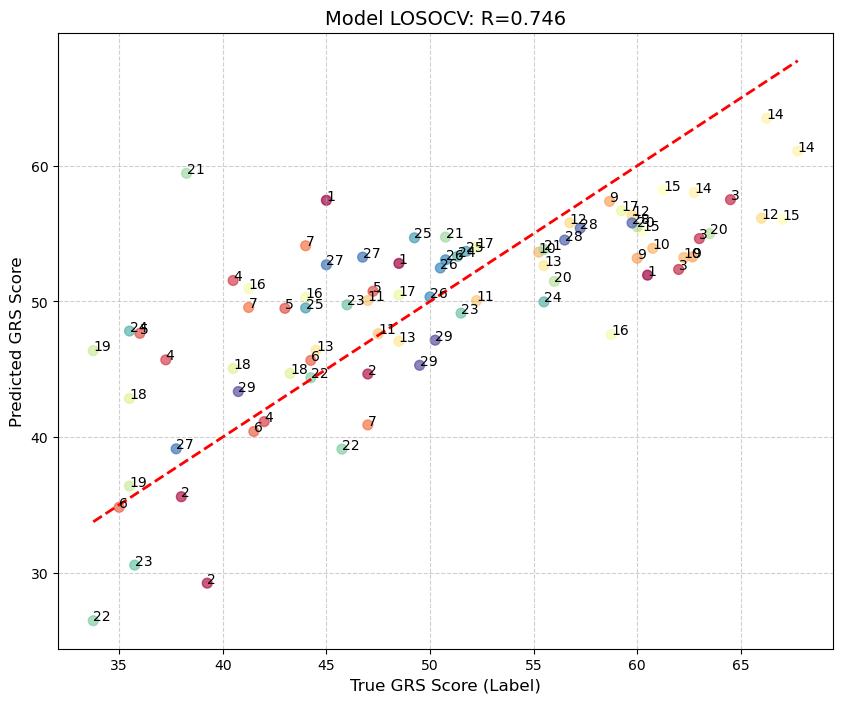

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and correctly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']]
additional_feature_cols = ['velocity_corr', 'BoW_13']  # palm_area_cv_median    idle_proportion    path_ratio_std    jerk_std
additional_pca_feature_cols = []#['path_ratio_std', 'palm_area_cv_median', 'path_ratio_median']
all_feature_cols = feature_cols + additional_feature_cols + additional_pca_feature_cols
X = comb_df[all_feature_cols].values
y = comb_df['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = comb_df['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier
unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]

    # second PCA with local features
    pca2 = PCA(n_components=min(2, len(additional_pca_feature_cols)))  # Adjust number of components as needed
    X_train_pca2 = pca2.fit_transform(X_train[:, -len(additional_pca_feature_cols):])
    X_test_pca2 = pca2.transform(X_test[:, -len(additional_pca_feature_cols):])
    n=1
    X_train_pca2 = X_train_pca2[:, :n]
    X_test_pca2 = X_test_pca2[:, :n]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):], X_train_pca2))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):], X_test_pca2))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()